# House Price Prediction System

The goal of this analysis is to accurately predict house prices based on various structural and location-related features. \
The key is to identify and understand primary drivers which impact house prices.

## Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor

## Load Dataset

The dataset contains information about residential properties, including features such as living area, number of bedrooms, construction year, and renovation status. \
The target variable is the house price.

In [2]:
df = pd.read_csv("../data/kc_house_data.csv")

print(df.shape)
print(df.columns)
df.head(5)

(21613, 21)
Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Check for Duplicates

In [3]:
df.info()
print(df.isna().sum())
print("Duplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

## Feature Engineering

To improve model performance, several new features were engineered. 

A key transformation was the creation of *house_age*, which captures the age of a property and *distance_to_center*, which reflects how close the property is to the center of the town. \
Another transformation was the addition of *years_since_renovation*, which focusses on how recently a house was updated. \
These features provide more meaningful representations of property condition than the raw year and location variables alone.

In [4]:
df["date"] = pd.to_datetime(df["date"])

df["house_age"] = datetime.now().year - df["yr_built"]

renovation_year = np.where(
    df["yr_renovated"] != 0,
    df["yr_renovated"],
    df["yr_built"]
)
df["years_since_renovation"] = datetime.now().year - renovation_year

center_lat = df["lat"].mean()
center_long = df["long"].mean()

df["distance_to_center"] = np.sqrt(
    (df["lat"] - center_lat)**2 + (df["long"] - center_long)**2
)

df.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,house_age,years_since_renovation,distance_to_center
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,1955,0,98178,47.5112,-122.257,1340,5650,71,71,0.065150
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,1951,1991,98125,47.7210,-122.319,1690,7639,75,35,0.192226
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,1933,0,98028,47.7379,-122.233,2720,8062,93,93,0.178871
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,1965,0,98136,47.5208,-122.393,1360,5000,61,61,0.183354
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,1987,0,98074,47.6168,-122.045,1800,7503,39,39,0.178175
5,7237550310,2014-05-12,1225000.0,4,4.50,5420,101930,1.0,0,0,...,2001,0,98053,47.6561,-122.005,4760,101930,25,25,0.229919
6,1321400060,2014-06-27,257500.0,3,2.25,1715,6819,2.0,0,0,...,1995,0,98003,47.3097,-122.327,2238,6819,31,31,0.274716
7,2008000270,2015-01-15,291850.0,3,1.50,1060,9711,1.0,0,0,...,1963,0,98198,47.4095,-122.315,1650,9711,63,63,0.181350
8,2414600126,2015-04-15,229500.0,3,1.00,1780,7470,1.0,0,0,...,1960,0,98146,47.5123,-122.337,1780,8113,66,66,0.132041
9,3793500160,2015-03-12,323000.0,3,2.50,1890,6560,2.0,0,0,...,2003,0,98038,47.3684,-122.031,2390,7570,23,23,0.264918


## Definition of Feature & Target

The next step is to compromise the full dataset into feature and target matrices.

### Feature Selection

To do that, feature columns are chosen and the X (feature) matrix is created.

In [5]:
X_columns = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade",
    "sqft_above",
    "sqft_basement",
    "house_age",
    "years_since_renovation",
    "distance_to_center"
]

X = df[X_columns].copy()
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,house_age,years_since_renovation,distance_to_center
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,71,71,0.065150
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,75,35,0.192226
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,93,93,0.178871
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,61,61,0.183354
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,39,39,0.178175


### Target Selection & Transformation

The y (target) matrix is chosen as the _price_ column.

In [6]:
y = df["price"].copy()

##### Distribution of y

The distribution of the *price* variable is inspected to establish if a logarithmic scale is advantageous for model stability (esp. residuals).

<Axes: xlabel='price', ylabel='Density'>

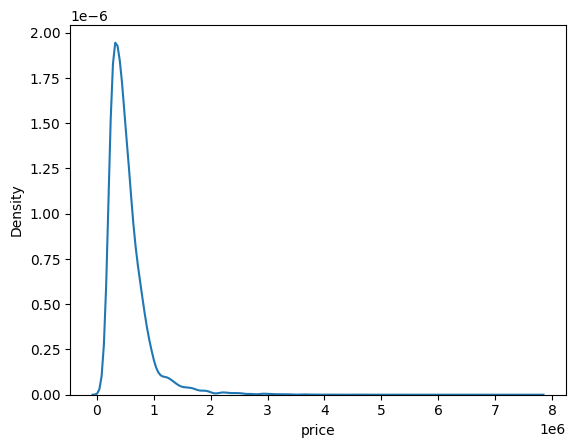

In [7]:
sns.kdeplot(
    data=y
)

The distribution is noticeably skewed to the right, so a logarithmic scale would be advantageous.

##### Transform y

In [8]:
y_log = np.log(y)

<Axes: xlabel='price', ylabel='Density'>

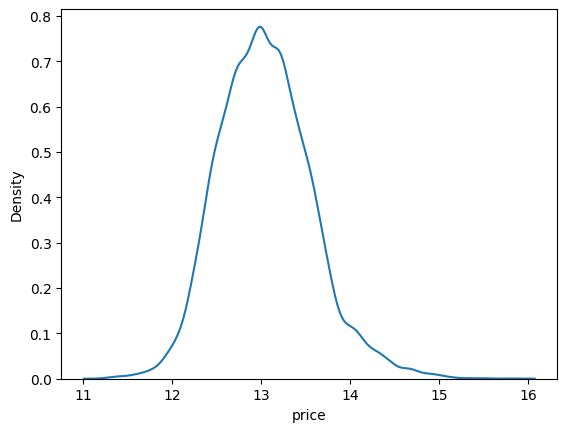

In [9]:
sns.kdeplot(
    data=y_log
)

The target variable is more similar to a normal distribution (more symmetric and centered), which ensures more stable residuals and lighter outliers.

## Model Training

### Train-Test Split

A train and test split is created to train the models on part of the data and test the efficiency of the models with the unseen test split. 

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log,
    test_size=0.2,
    random_state=42
)

### Pipeline

Several linear models were applied, including Linear Regression, Lasso, Ridge and ElasticNet. \
Regularized models were included to inspect the effect of model complexity and prevent overfitting.

In [11]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LinearRegression())
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("ls", Lasso(alpha=0.001))
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("rd", Ridge(alpha=10))
    ]),
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("en", ElasticNet(alpha=0.001, l1_ratio=0.1, max_iter=5000))
    ])
}

### Hyperparameter Tuning

To assist the decision of the hyperparameter choice, a grid search cross validation is performed for the 4 regression models.

*alpha* is the regularization parameter, which controls the penalty of significant errors.

#### Lasso Regression

Lasso Regression applies an L1 regularization penalty, which encourages sparsity in the model coefficients. \
As a result, some coefficients are driven exactly to zero, effectively performing feature selection.

In [12]:
param_grid = {
    "ls__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    models["Lasso"],
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'ls__alpha': 0.001}
Best score: 0.6657084696930522


#### Ridge Regression

Ridge Regression applies an L2 regularization penalty, which also encourages sparsity in the model coefficients. \
As a result, some coefficients are driven close to zero, performing feature weighting.

In [13]:
param_grid = {
    "rd__alpha": [0.001, 0.01, 0.1, 1, 10, 30, 100]
}

grid = GridSearchCV(
    models["Ridge"],
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'rd__alpha': 10}
Best score: 0.665734674790636


#### ElasticNet Regression

ElasticNet Regression applies a mixed regularization penalty of Lasso and Ridge, which encourages sparsity in the model coefficients as well. \
*l1_ratio* describes the ratio of L1 penalty with respect to the L2 penalty.

In [14]:
param_grid = {
    "en__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
    "en__l1_ratio": [0.1, 0.5, 0.9]
}

grid = GridSearchCV(
    models["ElasticNet"],
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'en__alpha': 0.001, 'en__l1_ratio': 0.1}
Best score: 0.6657339490239009


Hyperparameter tuning resulted in very small values for the regularization parameter, indicating that the dataset does not suffer from significant overfitting. \
As a result, regularized models behave similarly to ordinary linear regression.

### Fit Model 

After finding the hyperparameters the models are being trained on the training data (X_train, y_train).

In [15]:
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

### Example Predictions

Some example houses were established to show the predictions of the different models.

In [37]:
example_houses = pd.DataFrame([
{"bedrooms": 3, "bathrooms": 2.5, "sqft_living": 5400, "sqft_lot": 3200, "floors": 2, "waterfront": 0, "view": 1, "condition": 4, 
 "grade": 7, "sqft_above": 2000, "sqft_basement": 400, "house_age": 65, "years_since_renovation": 65, "distance_to_center": 1},
{"bedrooms": 5, "bathrooms": 4, "sqft_living": 7000, "sqft_lot": 4000, "floors": 2, "waterfront": 1, "view": 2, "condition": 5, 
 "grade": 9, "sqft_above": 4000, "sqft_basement": 1000, "house_age": 48, "years_since_renovation": 28, "distance_to_center":0.4},
{"bedrooms": 2, "bathrooms": 1.5, "sqft_living": 1000, "sqft_lot": 500, "floors": 1, "waterfront": 0, "view": 0, "condition": 2, 
 "grade": 5, "sqft_above": 0, "sqft_basement": 300, "house_age": 66, "years_since_renovation": 66, "distance_to_center":2.8}
])

example_houses

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,house_age,years_since_renovation,distance_to_center
0,3,2.5,5400,3200,2,0,1,4,7,2000,400,65,65,1.0
1,5,4.0,7000,4000,2,1,2,5,9,4000,1000,48,28,0.4
2,2,1.5,1000,500,1,0,0,2,5,0,300,66,66,2.8


In [36]:
results = []

for name, pipe in models.items():
    preds = pipe.predict(example_houses)
    preds_exp = np.exp(preds).round(2)

    result_row = {
        "Model": name
    }

    for i, pred in enumerate(preds_exp):
        result_row[f"Price House {i}"] = pred

    results.append(result_row)

df_results = pd.DataFrame(results)
df_results

,Model,Price House 0,Price House 1,Price House 2
0,Linear Regression,298324.42,1744383.13,14434.14
1,Lasso,375739.90,1996613.95,15754.89
2,Ridge,298473.93,1744456.02,14441.81
3,ElasticNet,334850.79,1879186.78,14893.66


The predictions across the models are relatively similar. \
Lasso Regression tends to produce the highest price estimates, while ElasticNet yields values between Ridge and Lasso, as it combines both L1 and L2 regularization. \
Linear Regression and Ridge Regression produce nearly identical predictions, indicating that regularization has little impact in this case.

### Model Evaluation

Model performance was evaluated using R², Mean Squared Error (MSE) and Root Mean Squared Error (RMSE). \
These metrics provide insight into both the explained variance and the magnitude of prediction errors.

In [19]:
results_metrics = []

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results_metrics.append({
        "Model": name,
        "R²": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred)
    })

results_metrics = pd.DataFrame(results_metrics).round(4)
results_metrics

,Model,R²,MSE,RMSE
0,Linear Regression,0.6764,0.0922,0.3037
1,Lasso,0.6765,0.0922,0.3037
2,Ridge,0.6764,0.0922,0.3037
3,ElasticNet,0.6764,0.0922,0.3037


The results show that all models achieve very similar performance. \
This suggests that the relationship between the features and the target variable is largely linear and does not require strong regularization.

## Coefficient Analysis

### Calculation

In [20]:
df_coefs = pd.DataFrame([
    models["Linear Regression"].named_steps["lr"].coef_, models["Lasso"].named_steps["ls"].coef_, models["Ridge"].named_steps["rd"].coef_, 
    models["ElasticNet"].named_steps["en"].coef_
]).round(3)

df_coefs.columns = X_train.columns

df_coefs.insert(0, "Model", models.keys())

df_coefs

,Model,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,house_age,years_since_renovation,distance_to_center
0,Linear Regression,-0.026,0.059,0.080,0.015,0.054,0.027,0.04,0.024,0.244,0.062,0.049,0.148,-0.009,-0.081
1,Lasso,-0.024,0.058,0.148,0.014,0.053,0.026,0.04,0.023,0.244,0.000,0.015,0.139,-0.000,-0.080
2,Ridge,-0.026,0.059,0.080,0.015,0.054,0.027,0.04,0.024,0.244,0.062,0.049,0.148,-0.008,-0.081
3,ElasticNet,-0.026,0.058,0.114,0.015,0.054,0.027,0.04,0.024,0.244,0.031,0.032,0.146,-0.007,-0.081


The coefficients of the different models are almost identical, further proving the linear nature of the data without the need for regularization.

### Visualization

In [21]:
models_coefs = {
    "Linear Regression": models["Linear Regression"].named_steps["lr"],
    "Lasso": models["Lasso"].named_steps["ls"],
    "Ridge": models["Ridge"].named_steps["rd"],
    "ElasticNet": models["ElasticNet"].named_steps["en"]
}

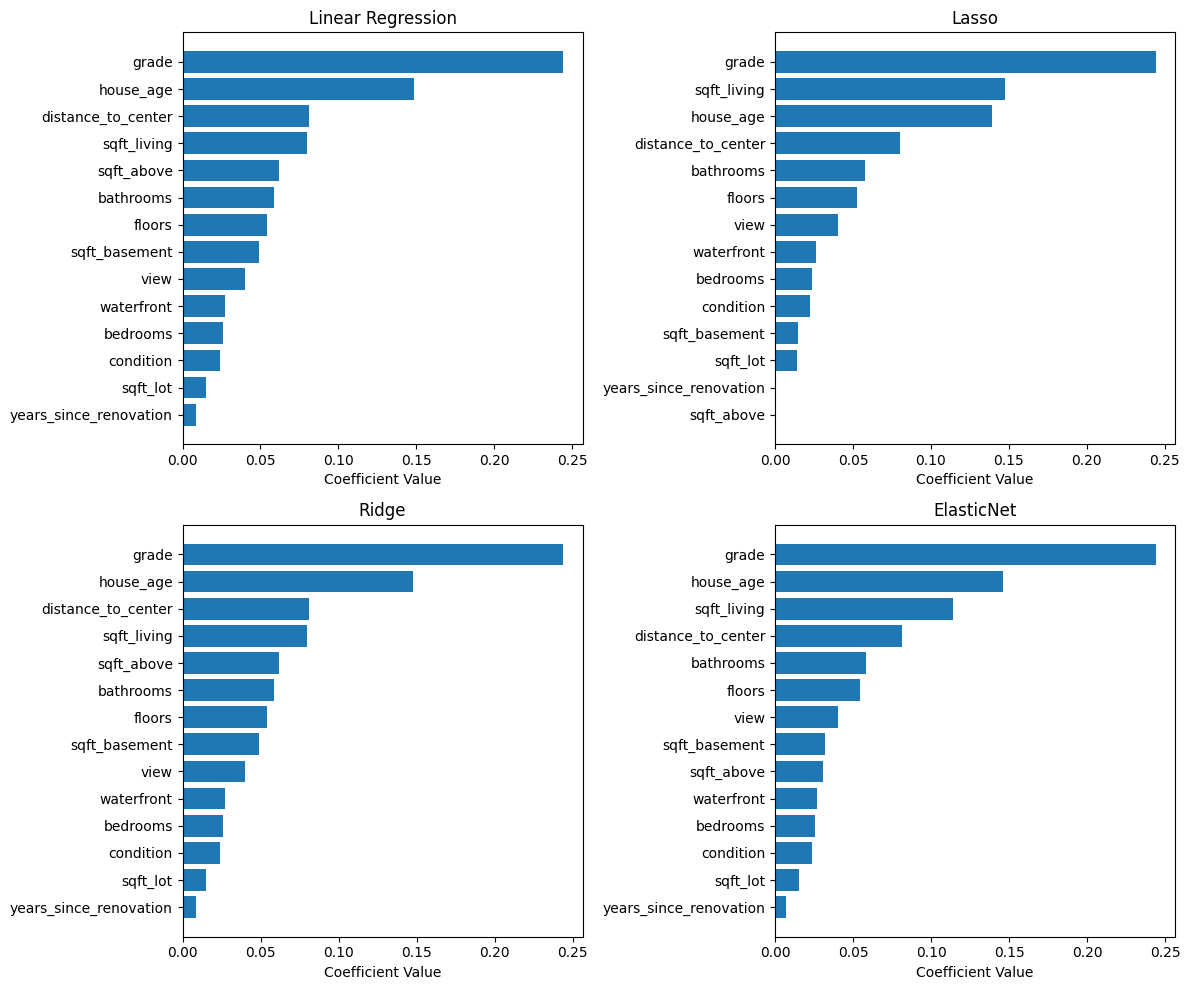

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models_coefs.items()):
    coefs = pd.Series(model.coef_, index=X_train.columns)

    coefs_abs = coefs.abs()

    coefs_sorted = coefs_abs.sort_values()

    axes[i].barh(coefs_sorted.index, coefs_sorted.values)
    axes[i].set_title(name)
    axes[i].set_xlabel("Coefficient Value")

plt.tight_layout()
plt.show()

The coefficient analysis shows which features are the main drivers of house prices. \
The grade, age, amount of living space and distance to center of the house seem to be key factors in determining the value of the property.

## Residual Analysis of Linear Regression

Residual Analysis is important to investigate how well the model represents the data. \
Various insights into how model errors behave can give a clear understanding of the models' fit.

### Residual Plot

The residual plot will give insights into possible patterns of the residuals, which would indicate a bad fit of a linear regressor with respect to the data.

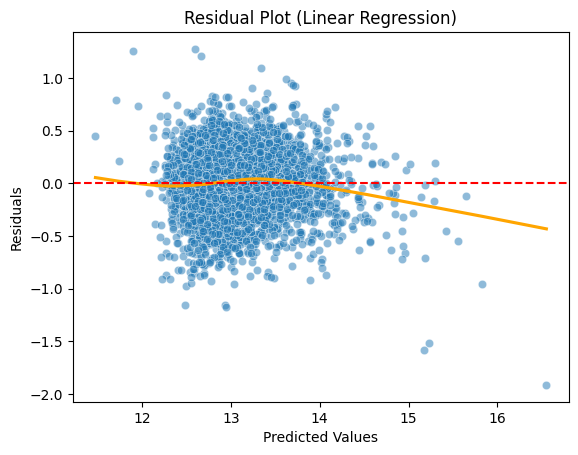

In [23]:
y_pred = models["Linear Regression"].predict(X_test)
residuals = y_test - y_pred

sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.5
)
sns.regplot(x=y_pred, y=residuals, scatter=False, lowess=True, color="orange")
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linear Regression)")
plt.show()

The residual plot reveals a slight curvature, indicating that the model does not fully capture non-linear relationships 
in the data. \
Most of the residuals are located randomly around zero, indicating that the model still captures the overall structure of the data reasonably well.

### Distribution of Residuals

The distribution of residuals should nearly follow a normal distribution, inducing many residuals close to zero and fewer far from zero. 

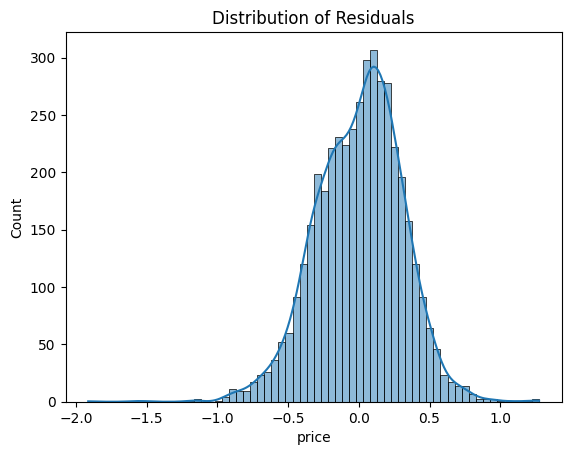

In [24]:
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

The residual distribution appears reminiscently normal, indicating a reasonable model fit. \
However, slight skewness and heavier tails suggest the presence of outliers or unexplained variability in the data.

### QQ-Plot

The QQ-Plot visualizes the deviation of residuals from the suspected distribution.

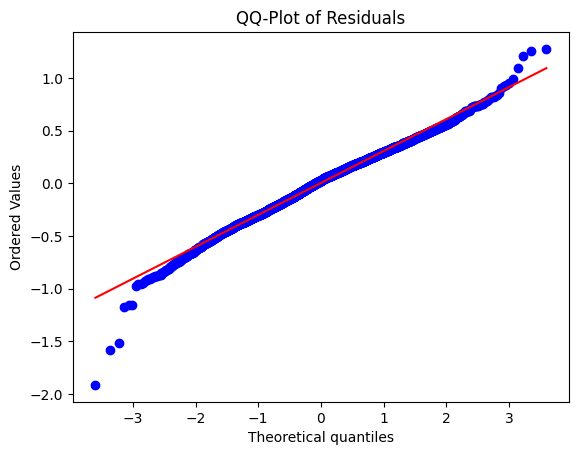

In [25]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")
plt.show()

The QQ plot confirms that the residuals follow a normal distribution closely in the central region. \
Deviations in the tails indicate that extreme values are not fully captured by the model.

### Predicted vs. True Values

This plot shows the relationship between predicted and actual house prices. \
The goal is to inspect whether values are systematically under- or overestimated.

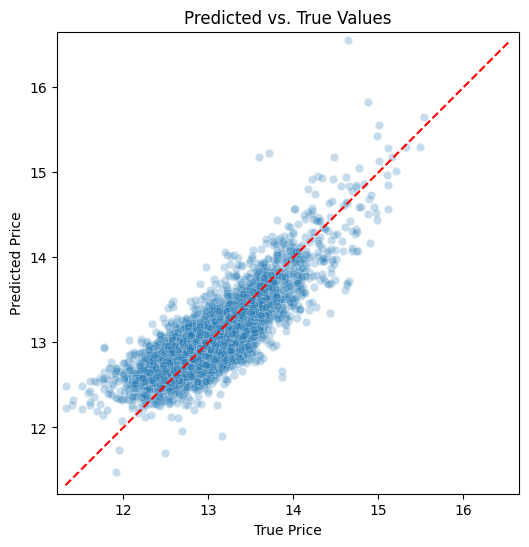

In [26]:
plt.figure(figsize=(6, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.25)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")

plt.xlim(min_val-0.1, max_val+0.1)
plt.ylim(min_val-0.1, max_val+0.1)

plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs. True Values")

plt.gca().set_aspect('equal', adjustable='box')

plt.show()

The predicted vs. true values plot shows a strong linear relationship, indicating that the model performs well overall. \
However, a systematic pattern can be observed: lower values tend to be overestimated, while higher values are slightly underestimated. \
This behavior is typical for linear models and may indicate that the relationship between features and target is not purely linear.

Overall, the diagnostics indicate that the linear model performs well for the majority of observations. \
Residuals are centered around zero and approximately normally distributed. \
However, systematic patterns in the residual plot and deviations in the QQ-Plot suggest that the model struggles to capture slight non-linear relationships and extreme values.

## Random Forest Regression (RFR)

To inspect the non-linear assumption, a non-linear regressor is applied: Random Forest Regressor. \
The goal is to get a grasp of the non-linearity of the house price data.

### Model Evaluation with RFR

First off, the same metrics (R², MSE and RMSE) are calculated for Random Forest Regression.

In [27]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

results_metrics = results_metrics.to_dict(orient="records")

results_metrics.append({
    "Model": "Random Forest Regressor",
    "R²": r2_score(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": root_mean_squared_error(y_test, y_pred)
})

results_metrics = pd.DataFrame(results_metrics).round(4)
results_metrics

,Model,R²,MSE,RMSE
0,Linear Regression,0.6764,0.0922,0.3037
1,Lasso,0.6765,0.0922,0.3037
2,Ridge,0.6764,0.0922,0.3037
3,ElasticNet,0.6764,0.0922,0.3037
4,Random Forest Regressor,0.7742,0.0644,0.2537


The Random Forest model achieves a higher R² and lower (R-)MSE compared to linear models, indicating that it is able to capture non-linear relationships in the data. \
However, the improvement is moderate, suggesting that the underlying structure of the data is largely linear.

## Residual Analysis of RFR

To further investigate the non-linearity of the data, a residual analysis was instigated for the Random Forest Regression as well.

### Residual Plot

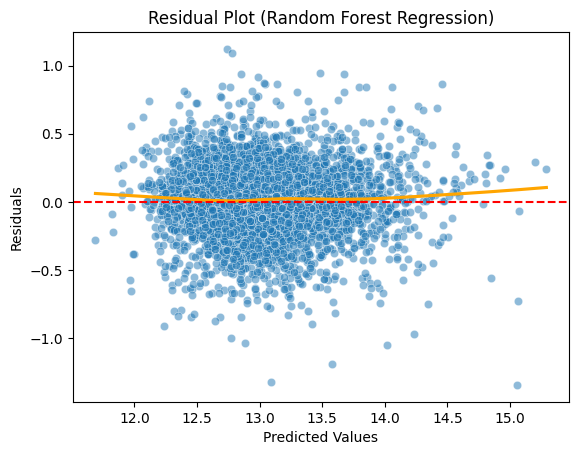

In [28]:
y_pred = rf.predict(X_test)
residuals = y_test - y_pred

sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.5
)
sns.regplot(x=y_pred, y=residuals, scatter=False, lowess=True, color="orange")
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest Regression)")
plt.show()

The Residual plot shows that the residuals are centered more around zero and are randomly spread. \
It indicates an improvement when non-linearity is taken into account.

### Distribution of Residuals

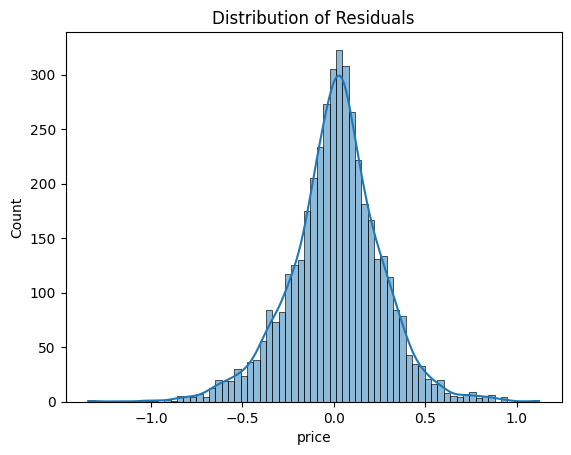

In [29]:
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

The distribution of residuals is centered more symmetrically around zero without very long tails. \
It shows that more residuals fall closer to zero which indicates a better model fit.

### QQ-Plot of Residuals

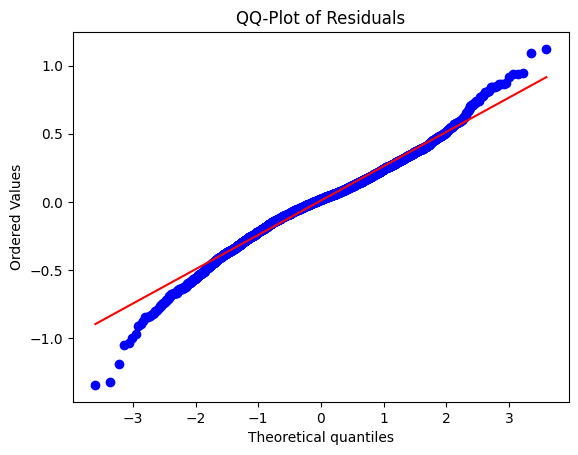

In [30]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")
plt.show()

The QQ plot indicates that the residuals follow a normal distribution closely in the central region, with minor deviations in the tails, suggesting improved 
model fit. \
Difficulties still show in capturing extreme values.

### Predicted vs True Values

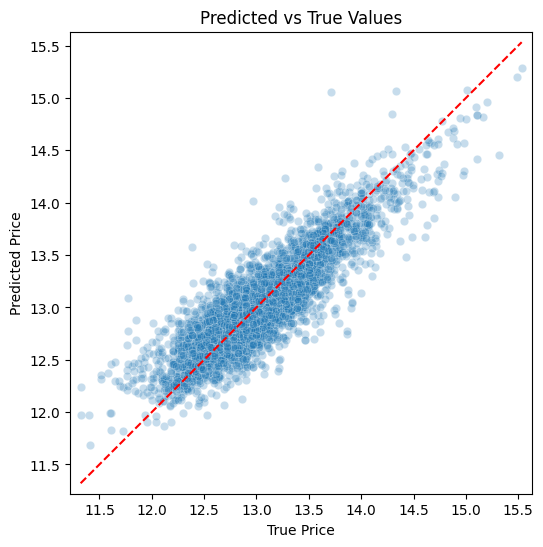

In [31]:
plt.figure(figsize=(6, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.25)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")

plt.xlim(min_val-0.1, max_val+0.1)
plt.ylim(min_val-0.1, max_val+0.1)

plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs True Values")

plt.gca().set_aspect('equal', adjustable='box')

plt.show()

The predicted vs. true values plot shows a tighter alignment along the diagonal compared to the linear model, indicating improved predictive performance.

Residual analysis of the linear model revealed systematic patterns, indicating non-linear relationships. \
After applying a Random Forest model, these patterns were reduced, confirming that the model successfully captures the slight non-linear structures in the data.

## Feature Importance

The feature importance analysis shows which features are the main drivers of house prices.

In [32]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

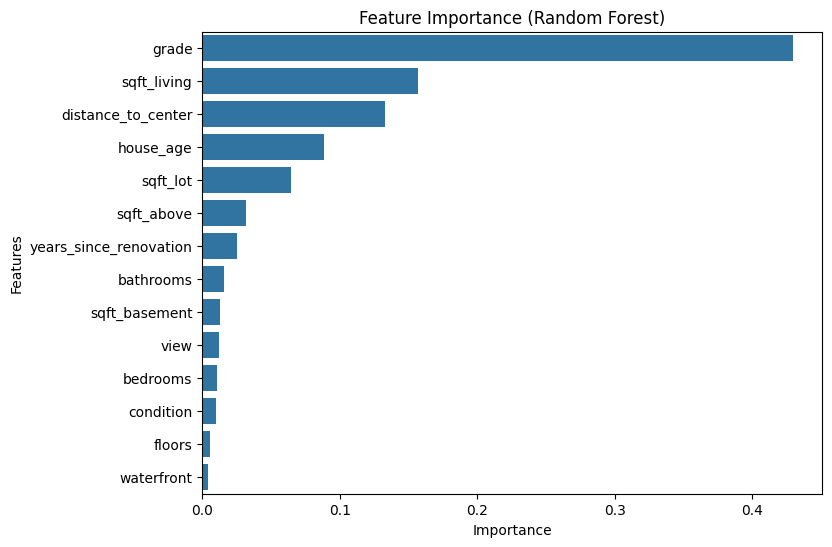

In [33]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=rf_importance.values,
    y=rf_importance.index
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

The grade of the house is by far the most influential feature. \
Besides that, amount of living space, distance to center and age of the house seem to be key factors in determining the value of the property.

## Summary

### Conclusion

Overall, the project demonstrates that: 
- Linear models provide a strong and interpretable baseline
- Feature engineering significantly improves performance
- Residual analysis is crucial for diagnosing model limitations
- Non-linear models such as Random Forest can further improve predictions by capturing complex relationships

### Future Work

Potential improvements include:
- More advanced feature engineering
- Testing additional non-linear models
- Exploring interaction effects between features